In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
from funs.prep_class import (
    EmulatedDataStorage,
    CaseDirectory,
    DataPrep,
    FeatureBuilder,
    Prep_Mask_Generation,
    visualize_emulation,
    meta_one_hot_shot,
)

In [4]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "test"
n_sample = 10000


ppe = xr.open_dataset("/glade/work/qingyuany/repo_data/spatialtuning/simv4_iteration1.nc")
obs = xr.open_dataset("/glade/work/qingyuany/repo_data/spatialtuning/obs.nc")


obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "clwp", "TMQ": "pwv",
         "CLDTOT_ISCCP": "clt_isccp", "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}





In [5]:
para = pd.read_csv("/glade/work/qingyuany/repo_data/spatialtuning/paras_v4.csv", index_col=0)
lat_bins = np.arange(-75, 76, 5)  # -90 to 90 every 10 degrees


In [6]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [7]:
man_sel_locations1 = pd.Series({"nm": "SWCF", "lat_min": -6,"lat_max": -4, "lon_min":  141, "lon_max": 144})
man_sel_locations2 = pd.Series({"nm": "SWCF", "lat_min": 7,"lat_max": 9, "lon_min":  235, "lon_max": 240})



manul_ppe_info = pd.concat([man_sel_locations1, man_sel_locations2], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,SWCF,-6,-4,141,144
1,SWCF,7,9,235,240


In [8]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, obs, obs_dict, para, lat_bins, manul_ppe_info)

Parameter and simulation indices match
nan variables matching between obs and simulation
Zonalized and manually selected obs and ppe written as csv


In [9]:
test_case.sensitivity_emulation(n_cpus = 15)

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

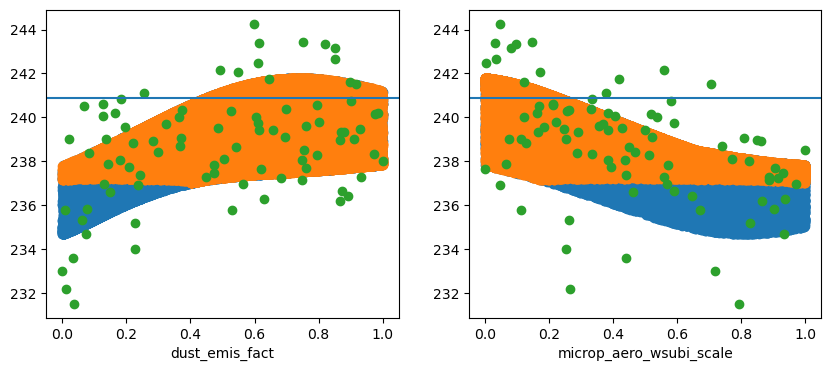

In [10]:

test_case.mask_generation()


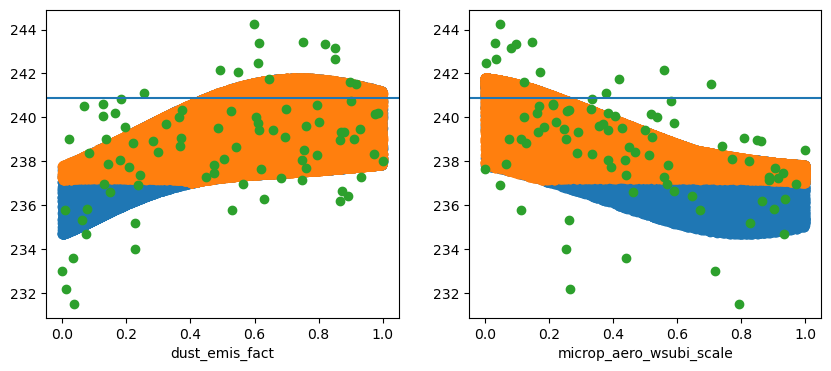

In [11]:
test_case.visualize_check('FLUT_zonal_35to40')

In [12]:
test_case.data_gcm.obs_pd

SWCF_zonal_-75to-70            -10.869088
SWCF_zonal_-70to-65            -30.565708
SWCF_zonal_-65to-60            -58.338633
SWCF_zonal_-60to-55            -68.259712
SWCF_zonal_-55to-50            -70.422472
                              ...        
FSNTOA_zonal_60to65            129.068726
FSNTOA_zonal_65to70            110.787786
FSNTOA_zonal_70to75             92.785553
SWCF_-6_-4_141_144     -64.97405462822577
SWCF_7_9_235_240       -76.31965532019917
Length: 235, dtype: object

In [21]:
test_case.data_emu.tf_masks.columns[test_case.data_emu.tf_masks.sum(axis = 0) < 10000 ]

Index(['TGCLDLWP_zonal_30to35', 'PRECT_zonal_40to45', 'FSNTOA_zonal_70to75',
       'PRECT_zonal_-75to-70', 'PRECT_zonal_0to5', 'TGCLDLWP_zonal_40to45',
       'CLDTOT_ISCCP_zonal_20to25', 'CLDTOT_ISCCP_zonal_25to30',
       'FLUT_zonal_65to70', 'TMQ_zonal_65to70', 'PRECT_zonal_-15to-10',
       'PRECT_zonal_-45to-40', 'PRECT_zonal_65to70', 'PRECT_zonal_-10to-5',
       'FSNTOA_zonal_65to70', 'TGCLDLWP_zonal_-40to-35', 'PRECT_zonal_60to65',
       'TMQ_zonal_60to65', 'TMQ_zonal_-70to-65', 'TMQ_zonal_70to75',
       'PRECT_zonal_-20to-15', 'PRECT_zonal_50to55', 'TMQ_zonal_-65to-60',
       'CLDTOT_ISCCP_zonal_40to45', 'TGCLDLWP_zonal_-20to-15',
       'CLDTOT_ISCCP_zonal_30to35', 'LWCF_zonal_-75to-70',
       'PRECT_zonal_-40to-35', 'TGCLDLWP_zonal_-45to-40', 'FLUT_zonal_60to65',
       'PRECT_zonal_-50to-45', 'CLDTOT_ISCCP_zonal_45to50',
       'PRECT_zonal_15to20', 'SWCF_zonal_70to75', 'SWCF_zonal_-70to-65',
       'TGCLDLWP_zonal_55to60', 'PRECT_zonal_5to10', 'TGCLDLWP_zonal_35to40',

In [27]:
tf_masks_summary = test_case.data_emu.tf_masks.sum(axis = 0)


tf_masks_summary[tf_masks_summary < 100].index

Index(['TGCLDLWP_zonal_30to35', 'PRECT_zonal_40to45', 'FSNTOA_zonal_70to75',
       'PRECT_zonal_-75to-70', 'PRECT_zonal_0to5', 'TGCLDLWP_zonal_40to45',
       'CLDTOT_ISCCP_zonal_20to25', 'CLDTOT_ISCCP_zonal_25to30',
       'FLUT_zonal_65to70', 'TMQ_zonal_65to70', 'PRECT_zonal_-15to-10',
       'PRECT_zonal_-45to-40', 'PRECT_zonal_65to70', 'PRECT_zonal_-10to-5',
       'FSNTOA_zonal_65to70', 'TGCLDLWP_zonal_-40to-35', 'PRECT_zonal_60to65',
       'TMQ_zonal_60to65', 'TMQ_zonal_-70to-65', 'TMQ_zonal_70to75',
       'PRECT_zonal_-20to-15', 'PRECT_zonal_50to55', 'TMQ_zonal_-65to-60',
       'CLDTOT_ISCCP_zonal_40to45', 'TGCLDLWP_zonal_-20to-15',
       'CLDTOT_ISCCP_zonal_30to35', 'LWCF_zonal_-75to-70',
       'PRECT_zonal_-40to-35', 'TGCLDLWP_zonal_-45to-40',
       'PRECT_zonal_-50to-45', 'CLDTOT_ISCCP_zonal_45to50',
       'PRECT_zonal_15to20', 'SWCF_zonal_70to75', 'SWCF_zonal_-70to-65',
       'TGCLDLWP_zonal_55to60', 'PRECT_zonal_5to10', 'TGCLDLWP_zonal_35to40',
       'PRECT_zonal_